In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
import xgboost as xgb
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

In [2]:
df = pd.read_csv('bitcoin.csv')

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2713 entries, 0 to 2712
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       2713 non-null   str    
 1   Open       2713 non-null   float64
 2   High       2713 non-null   float64
 3   Low        2713 non-null   float64
 4   Close      2713 non-null   float64
 5   Adj Close  2713 non-null   float64
 6   Volume     2713 non-null   float64
dtypes: float64(6), str(1)
memory usage: 172.3 KB


In [4]:
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,9/17/2014,465.864014,468.174011,452.421997,457.334015,457.334015,21056800.0
1,9/18/2014,456.859985,456.859985,413.104004,424.440002,424.440002,34483200.0
2,9/19/2014,424.102997,427.834991,384.532013,394.795990,394.795990,37919700.0
3,9/20/2014,394.673004,423.295990,389.882996,408.903992,408.903992,36863600.0
4,9/21/2014,408.084991,412.425995,393.181000,398.821014,398.821014,26580100.0


In [5]:
df.describe()

,Open,High,Low,Close,Adj Close,Volume
count,2713.000000,2713.000000,2713.000000,2713.000000,2713.000000,2.713000e+03
mean,11311.041069,11614.292482,10975.555058,11323.914637,11323.914637,1.470462e+10
std,16106.428892,16537.390649,15608.572561,16110.365010,16110.365010,2.001627e+10
min,176.897003,211.731003,171.509995,178.102997,178.102997,5.914570e+06
25%,606.396973,609.260986,604.109985,606.718994,606.718994,7.991080e+07
50%,6301.569824,6434.617676,6214.220215,6317.609863,6317.609863,5.098183e+09
75%,10452.399410,10762.644530,10202.387700,10462.259770,10462.259770,2.456992e+10
max,67549.734380,68789.625000,66382.062500,67566.828130,67566.828130,3.509680e+11


In [6]:
df.ffill(inplace=True)

,Date,Open,High,Low,Close,Adj Close,Volume
0,9/17/2014,465.864014,468.174011,452.421997,457.334015,457.334015,2.105680e+07
1,9/18/2014,456.859985,456.859985,413.104004,424.440002,424.440002,3.448320e+07
2,9/19/2014,424.102997,427.834991,384.532013,394.795990,394.795990,3.791970e+07
3,9/20/2014,394.673004,423.295990,389.882996,408.903992,408.903992,3.686360e+07
4,9/21/2014,408.084991,412.425995,393.181000,398.821014,398.821014,2.658010e+07
...,...,...,...,...,...,...,...
2708,2/15/2022,42586.464840,44667.218750,42491.035160,44575.203130,44575.203130,2.272166e+10
2709,2/16/2022,44578.277340,44578.277340,43456.691410,43961.859380,43961.859380,1.979255e+10
2710,2/17/2022,43937.070310,44132.972660,40249.371090,40538.011720,40538.011720,2.624666e+10
2711,2/18/2022,40552.132810,40929.152340,39637.617190,40030.976560,40030.976560,2.331001e+10


In [7]:
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

In [8]:
df['SMA_20'] = df['Close'].rolling(window=20).mean()
df['EMA_20'] = df['Close'].ewm(span=20, adjust=False).mean()

In [9]:
df['BB_std'] = df['Close'].rolling(window=20).std()
df['BB_Upper'] = df['SMA_20'] + (df['BB_std'] * 2)
df['BB_Lower'] = df['SMA_20'] - (df['BB_std'] * 2)

In [10]:
delta = df['Close'].diff(1)
gain = delta.where(delta > 0, 0)
loss = -delta.where(delta < 0, 0)
avg_gain = gain.rolling(window=14).mean()
avg_loss = loss.rolling(window=14).mean()
rs = avg_gain / avg_loss
df['RSI'] = 100 - (100 / (1 + rs))

In [11]:
df.dropna(inplace=True)

In [12]:
scaler = MinMaxScaler()
scaled_array = scaler.fit_transform(df)
df_scaled = pd.DataFrame(scaled_array, columns=df.columns, index=df.index)

In [13]:
train_size = int(len(df_scaled) * 0.8)
train_df = df_scaled.iloc[:train_size]
test_df = df_scaled.iloc[train_size:]

In [14]:
df.shape

(2694, 12)

In [15]:
train_df.shape

(2155, 12)

In [16]:
test_df.shape

(539, 12)

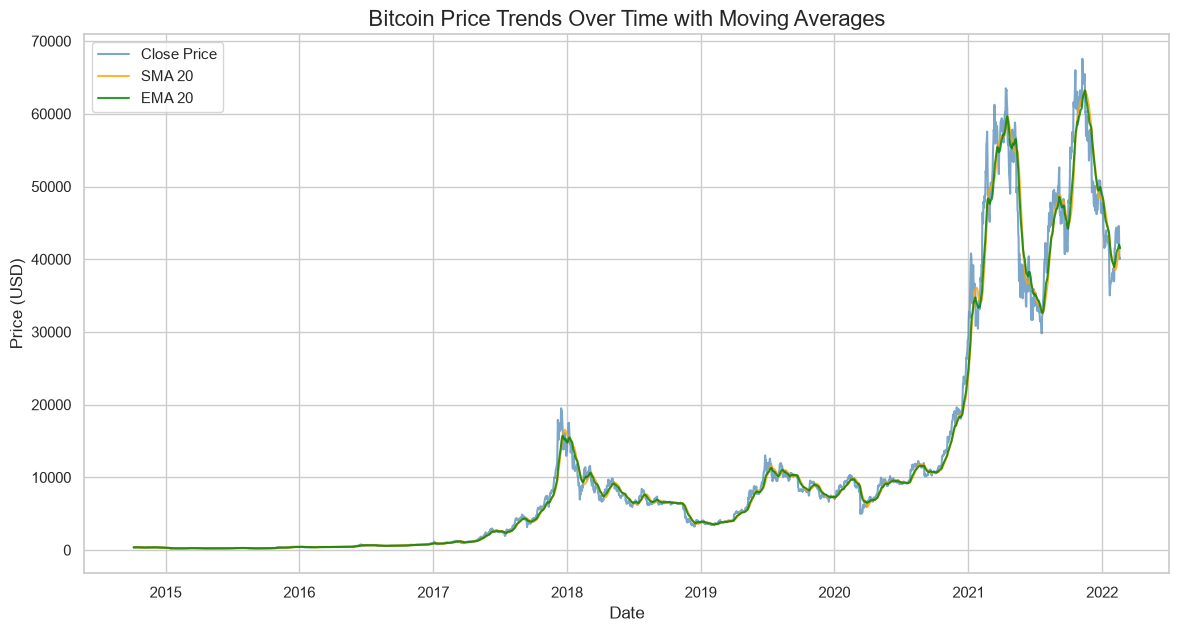

In [17]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 7))
plt.plot(df.index, df['Close'], label='Close Price', color='steelblue', alpha=0.7)
plt.plot(df.index, df['SMA_20'], label='SMA 20', color='orange', alpha=0.8)
plt.plot(df.index, df['EMA_20'], label='EMA 20', color='green', alpha=0.8)
plt.title('Bitcoin Price Trends Over Time with Moving Averages', fontsize=16)
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.show()

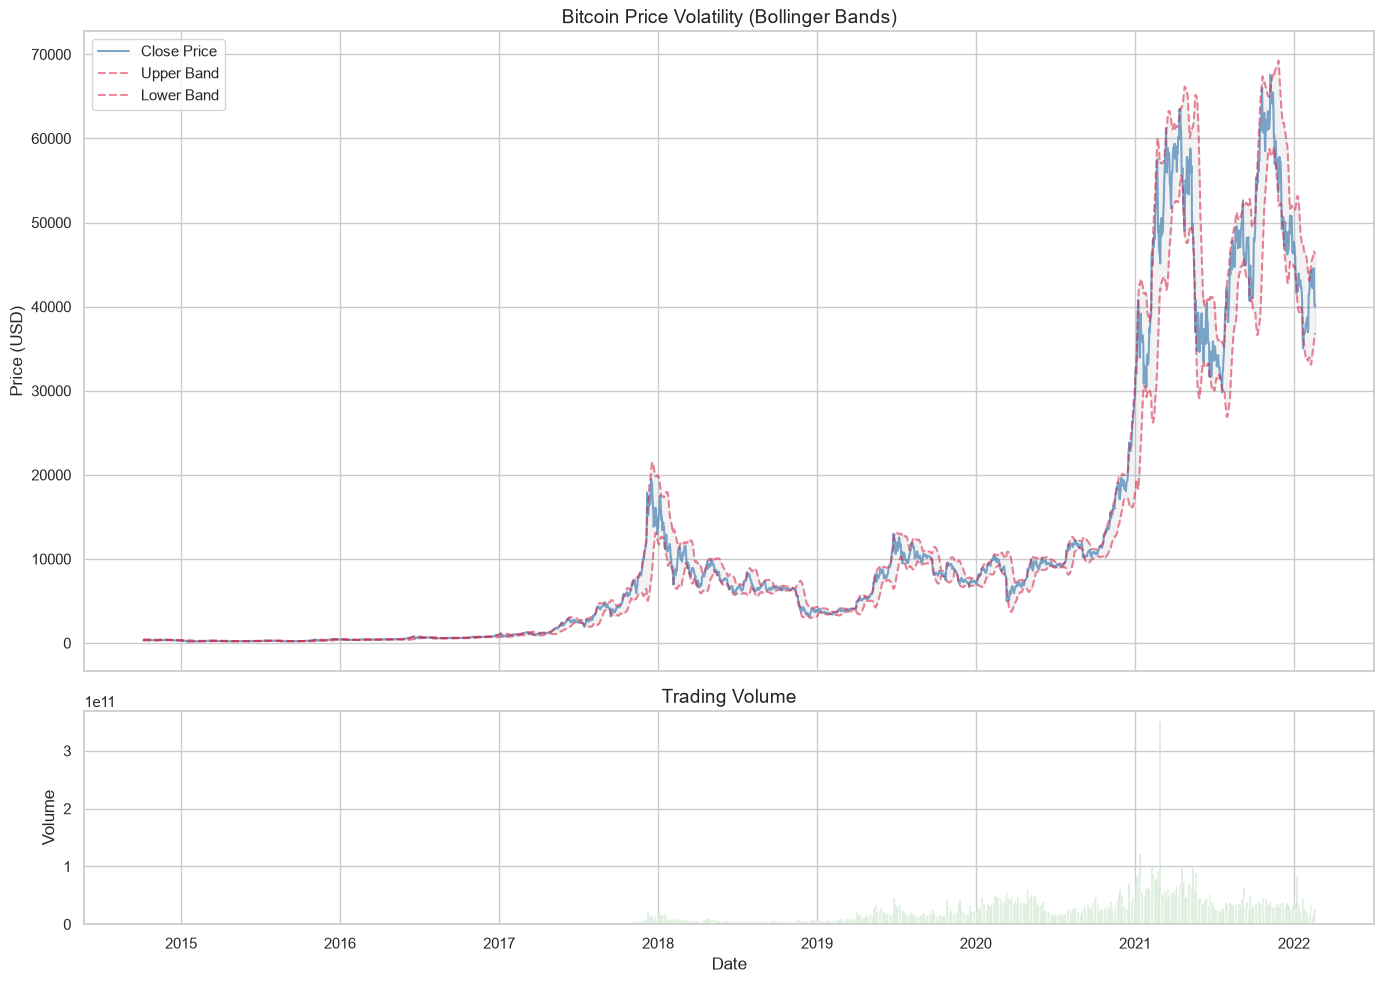

In [18]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), gridspec_kw={'height_ratios': [3, 1]}, sharex=True)

ax1.plot(df.index, df['Close'], label='Close Price', color='steelblue', alpha=0.7)
ax1.plot(df.index, df['BB_Upper'], label='Upper Band', color='crimson', linestyle='--', alpha=0.5)
ax1.plot(df.index, df['BB_Lower'], label='Lower Band', color='crimson', linestyle='--', alpha=0.5)
ax1.fill_between(df.index, df['BB_Lower'], df['BB_Upper'], color='grey', alpha=0.1)
ax1.set_title('Bitcoin Price Volatility (Bollinger Bands)', fontsize=14)
ax1.set_ylabel('Price (USD)')
ax1.legend()

ax2.bar(df.index, df['Volume'], color='green', alpha=0.5)
ax2.set_title('Trading Volume', fontsize=14)
ax2.set_ylabel('Volume')
ax2.set_xlabel('Date')
plt.tight_layout()
plt.show()

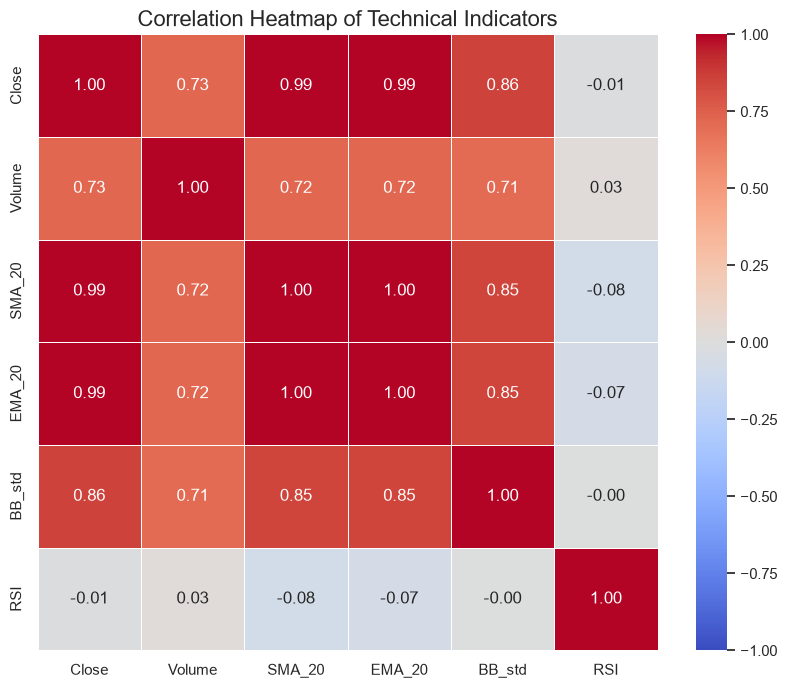

In [19]:
plt.figure(figsize=(10, 8))
indicator_cols = ['Close', 'Volume', 'SMA_20', 'EMA_20', 'BB_std', 'RSI']
corr_matrix = df[indicator_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)
plt.title('Correlation Heatmap of Technical Indicators', fontsize=16)
plt.show()

In [20]:
train_df_target = train_df['Close'].shift(-1)
test_df_target = test_df['Close'].shift(-1)

In [21]:
X_train = train_df.drop('Close', axis=1)[:-1]
y_train = train_df_target.dropna()

X_test = test_df.drop('Close', axis=1)[:-1]
y_test = test_df_target.dropna()

In [22]:
results = {}

In [23]:
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_preds = lr.predict(X_test)
results['Linear Regression'] = np.sqrt(mean_squared_error(y_test, lr_preds))

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)
results['Random Forest'] = np.sqrt(mean_squared_error(y_test, rf_preds))

svm = SVR(kernel='rbf')
svm.fit(X_train, y_train)
svm_preds = svm.predict(X_test)
results['SVM'] = np.sqrt(mean_squared_error(y_test, svm_preds))

xgb_model = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=100, random_state=42)
xgb_model.fit(X_train, y_train)
xgb_preds = xgb_model.predict(X_test)
results['XGBoost'] = np.sqrt(mean_squared_error(y_test, xgb_preds))

In [24]:
X_train_lstm = np.reshape(X_train.values, (X_train.shape[0], 1, X_train.shape[1]))
X_test_lstm = np.reshape(X_test.values, (X_test.shape[0], 1, X_test.shape[1]))

lstm = Sequential()
lstm.add(LSTM(50, return_sequences=False, input_shape=(X_train_lstm.shape[1], X_train_lstm.shape[2])))
lstm.add(Dense(1)) # Output layer predicting 1 value

lstm.compile(optimizer='adam', loss='mean_squared_error')
lstm.fit(X_train_lstm, y_train, epochs=20, batch_size=32, verbose=0)

lstm_preds = lstm.predict(X_test_lstm)
results['LSTM'] = np.sqrt(mean_squared_error(y_test, lstm_preds.flatten()))

C:\Users\aeman\AppData\Roaming\Python\Python311\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


In [25]:
sorted_results = dict(sorted(results.items(), key=lambda item: item[1]))

In [26]:
for model, rmse in sorted_results.items():
    print(f"{model}: {rmse:.6f}")

Linear Regression: 0.024323
LSTM: 0.054134
Random Forest: 0.410916
XGBoost: 0.422605
SVM: 0.508097


In [27]:
import requests

In [28]:
mae = mean_absolute_error(y_test, lr_preds)
mse = mean_squared_error(y_test, lr_preds)
r2 = r2_score(y_test, lr_preds)

print(f"Mean Absolute Error (MAE): {mae:.6f}")
print(f"Mean Squared Error (MSE):  {mse:.6f}")
print(f"R-squared (R2) Score:      {r2:.6f}")

Mean Absolute Error (MAE): 0.016851
Mean Squared Error (MSE):  0.000592
R-squared (R2) Score:      0.989175


In [29]:
url = "https://api.binance.com/api/v3/klines"
params = {
    'symbol': 'BTCUSDT',
    'interval': '1d',
    'limit': 60
}

response = requests.get(url, params=params)
data = response.json()

In [30]:
live_df = pd.DataFrame(data, columns=[
    'Open_time', 'Open', 'High', 'Low', 'Close', 'Volume', 
    'Close_time', 'Quote_asset_volume', 'Number_of_trades', 
    'Taker_buy_base_asset_volume', 'Taker_buy_quote_asset_volume', 'Ignore'
])

In [31]:
live_df['Date'] = pd.to_datetime(live_df['Open_time'], unit='ms')
live_df.set_index('Date', inplace=True)

In [32]:
cols_to_keep = ['Open', 'High', 'Low', 'Close', 'Volume']
live_df = live_df[cols_to_keep].astype(float)
live_df['Adj Close'] = live_df['Close']
live_df = live_df[['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']]

In [33]:
live_df['SMA_20'] = live_df['Close'].rolling(window=20).mean()
live_df['EMA_20'] = live_df['Close'].ewm(span=20, adjust=False).mean()

live_df['BB_std'] = live_df['Close'].rolling(window=20).std()
live_df['BB_Upper'] = live_df['SMA_20'] + (live_df['BB_std'] * 2)
live_df['BB_Lower'] = live_df['SMA_20'] - (live_df['BB_std'] * 2)

delta = live_df['Close'].diff(1)
gain = delta.where(delta > 0, 0)
loss = -delta.where(delta < 0, 0)
avg_gain = gain.rolling(window=14).mean()
avg_loss = loss.rolling(window=14).mean()
rs = avg_gain / avg_loss
live_df['RSI'] = 100 - (100 / (1 + rs))

live_df.dropna(inplace=True)

In [34]:
live_scaled_array = scaler.transform(live_df)
live_df_scaled = pd.DataFrame(live_scaled_array, columns=live_df.columns, index=live_df.index)

In [35]:
X_live = live_df_scaled.drop('Close', axis=1).iloc[[-1]]

In [36]:
scaled_prediction = lr.predict(X_live)[0]

In [37]:
dummy_array = np.zeros((1, len(live_df.columns)))
close_col_index = list(live_df.columns).index('Close')
dummy_array[0, close_col_index] = scaled_prediction
actual_usd_prediction = scaler.inverse_transform(dummy_array)[0, close_col_index]

In [38]:
print(f"\nToday's Actual Last Close Price: ${live_df['Close'].iloc[-1]:,.2f}")
print(f"Predicted Trend for Tomorrow:    ${actual_usd_prediction:,.2f}")
if actual_usd_prediction > live_df['Close'].iloc[-1]:
    print("Trend Indicator: 📈 UPWARD TREND")
else:
    print("Trend Indicator: 📉 DOWNWARD TREND")


Today's Actual Last Close Price: $63,207.21
Predicted Trend for Tomorrow:    $63,002.94
Trend Indicator: 📉 DOWNWARD TREND
